In [1]:
# 'pandas' lets us load and work with tabular data
import pandas as pd

# Load our already-cleaned dataset from Task 2
df = pd.read_csv("churn_cleaned.csv")

# Quick confirmation
print("Shape:", df.shape)
print(df.head())

Shape: (3333, 70)
   Account length  Area code  International plan  Voice mail plan  \
0        0.676489  -0.523603                   0                1   
1        0.149065  -0.523603                   0                1   
2        0.902529  -0.523603                   0                0   
3       -0.428590  -0.688834                   1                0   
4       -0.654629  -0.523603                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0               1.234883           1.566767         0.476643   
1               1.307948          -0.333738         1.124503   
2              -0.591760           1.168304         0.675985   
3              -0.591760           2.196596        -1.466936   
4              -0.591760          -0.240090         0.626149   

   Total day charge  Total eve minutes  Total eve calls  ...  State_SD  \
0          1.567036          -0.070610        -0.055940  ...     False   
1         -0.334013          -0.10

In [2]:
# Overall statistical summary (same tool we used in Task 2)
print("=== Overall summary (.describe()) ===")
print(df.describe())

# Let's also compute a few specific stats individually, for one key column
print("\n=== Focused stats on 'Total day minutes' ===")
print("Mean:", df["Total day minutes"].mean())
print("Median:", df["Total day minutes"].median())
print("Variance:", df["Total day minutes"].var())
print("Standard deviation:", df["Total day minutes"].std())

=== Overall summary (.describe()) ===
       Account length     Area code  International plan  Voice mail plan  \
count    3.333000e+03  3.333000e+03         3333.000000      3333.000000   
mean     1.449652e-16  4.199728e-16            0.096910         0.276628   
std      1.000150e+00  1.000150e+00            0.295879         0.447398   
min     -2.513172e+00 -6.888343e-01            0.000000         0.000000   
25%     -6.797448e-01 -6.888343e-01            0.000000         0.000000   
50%     -1.627644e-03 -5.236033e-01            0.000000         0.000000   
75%      6.513740e-01  1.718817e+00            0.000000         1.000000   
max      3.564766e+00  1.718817e+00            1.000000         1.000000   

       Number vmail messages  Total day minutes  Total day calls  \
count           3.333000e+03       3.333000e+03     3.333000e+03   
mean            7.994405e-17      -3.165784e-16    -1.828054e-16   
std             1.000150e+00       1.000150e+00     1.000150e+00   
min  

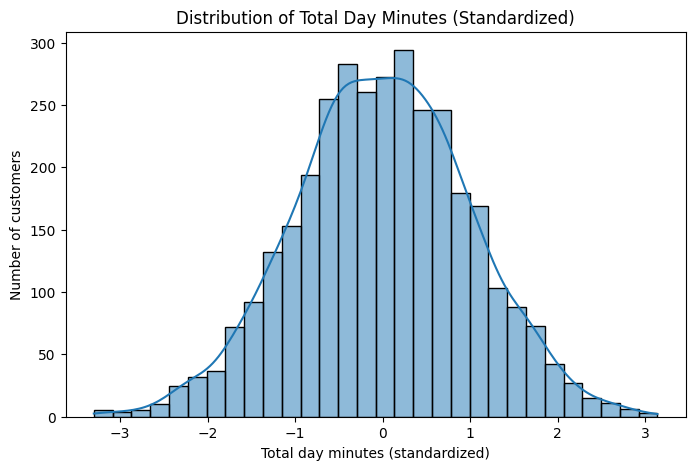

In [3]:
# matplotlib is the core Python plotting library
import matplotlib.pyplot as plt

# seaborn builds on matplotlib, with nicer default styles and easier syntax
import seaborn as sns

# Create a histogram of "Total day minutes"
plt.figure(figsize=(8, 5))
sns.histplot(df["Total day minutes"], bins=30, kde=True)
plt.title("Distribution of Total Day Minutes (Standardized)")
plt.xlabel("Total day minutes (standardized)")
plt.ylabel("Number of customers")
plt.show()

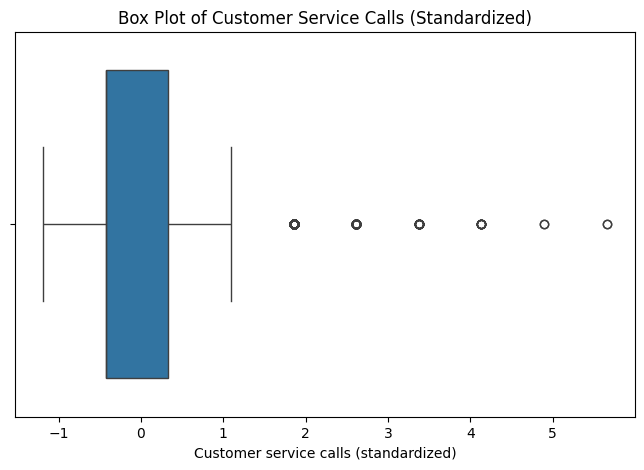

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Customer service calls"])
plt.title("Box Plot of Customer Service Calls (Standardized)")
plt.xlabel("Customer service calls (standardized)")
plt.show()

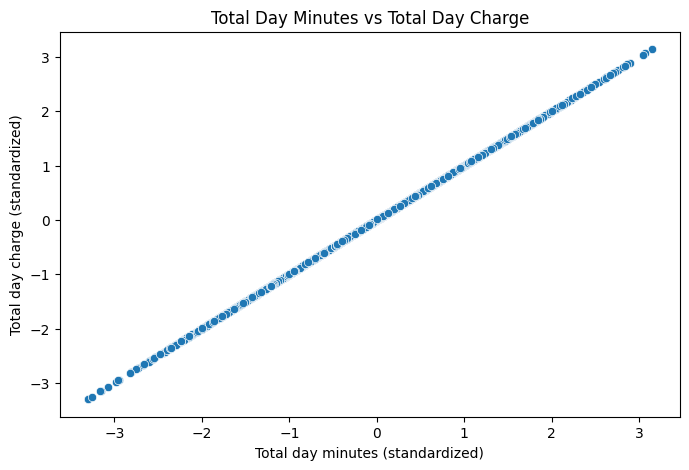

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Total day minutes"], y=df["Total day charge"])
plt.title("Total Day Minutes vs Total Day Charge")
plt.xlabel("Total day minutes (standardized)")
plt.ylabel("Total day charge (standardized)")
plt.show()

In [9]:
# Let's focus on the core numeric columns (excluding the many State_ columns for now)
core_cols = [
    "Account length", "Number vmail messages",
    "Total day minutes", "Total day calls", "Total day charge",
    "Total eve minutes", "Total eve calls", "Total eve charge",
    "Total night minutes", "Total night calls", "Total night charge",
    "Total intl minutes", "Total intl calls", "Total intl charge",
    "Customer service calls", "Churn"
]

# Compute the correlation matrix
corr_matrix = df[core_cols].corr()

# Display it
print(corr_matrix)

                        Account length  Number vmail messages  \
Account length                1.000000              -0.004628   
Number vmail messages        -0.004628               1.000000   
Total day minutes             0.006216               0.000778   
Total day calls               0.038470              -0.009548   
Total day charge              0.006214               0.000776   
Total eve minutes            -0.006757               0.017562   
Total eve calls               0.019260              -0.005864   
Total eve charge             -0.006745               0.017578   
Total night minutes          -0.008955               0.007681   
Total night calls            -0.013176               0.007123   
Total night charge           -0.008960               0.007663   
Total intl minutes            0.009514               0.002856   
Total intl calls              0.020661               0.013957   
Total intl charge             0.009546               0.002884   
Customer service calls   

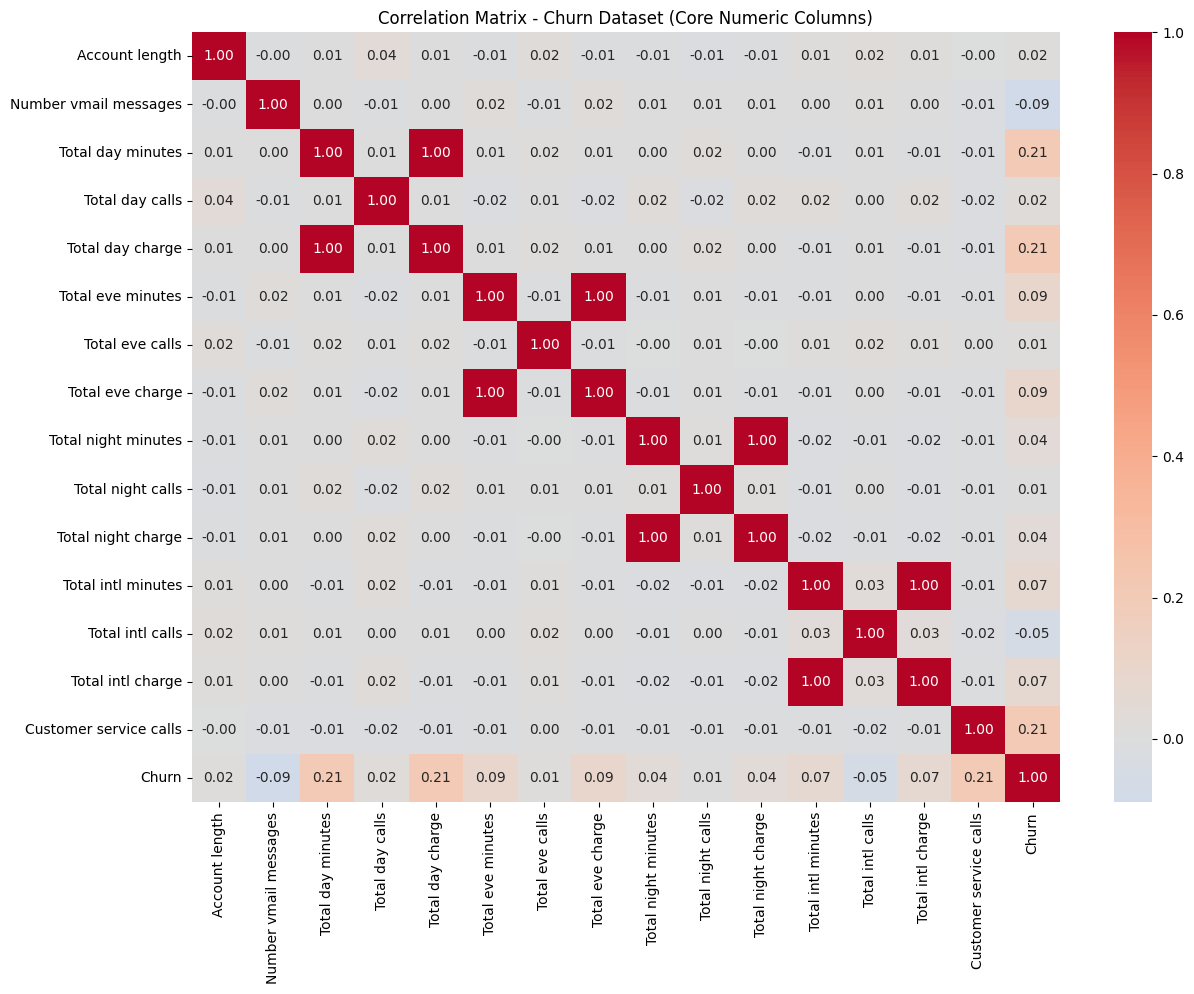

In [10]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Churn Dataset (Core Numeric Columns)")
plt.show()